In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
                             f1_score,roc_auc_score,confusion_matrix,classification_report,ConfusionMatrixDisplay)


c:\Users\dell\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


<h1>Dataset informations</h1>

In [2]:
df=pd.read_csv("data/teams_match_features.csv")
df.head()

,_tournament,_date,_home_team,_away_team,home_goals,away_goals,is_neutral,is_world_cup,is_continental,home_form_scored,...,away_avg_defense,away_avg_pace,away_avg_shooting,away_avg_passing,overall_diff,attack_diff,defense_diff,home_elo,away_elo,elo_diff
0,Friendly,1872-11-30,Scotland,England,0,0,0,0,0,1.500000,...,81.222222,73.538462,69.923077,71.307692,-7.214286,-7.75,-6.972222,1500.000000,1500.000000,0.000000
1,Friendly,1873-03-08,England,Scotland,4,2,0,0,0,0.000000,...,74.250000,71.083333,69.500000,69.583333,7.214286,7.75,6.972222,1500.000000,1500.000000,0.000000
2,Friendly,1874-03-07,Scotland,England,2,1,0,0,0,1.000000,...,81.222222,73.538462,69.923077,71.307692,-7.214286,-7.75,-6.972222,1484.000000,1516.000000,-32.000000
3,Friendly,1875-03-06,England,Scotland,2,2,0,0,0,1.666667,...,74.250000,71.083333,69.500000,69.583333,7.214286,7.75,6.972222,1498.530498,1501.469502,-2.939003
4,Friendly,1876-03-04,Scotland,England,3,0,0,0,0,1.500000,...,81.222222,73.538462,69.923077,71.307692,-7.214286,-7.75,-6.972222,1501.334159,1498.665841,2.668317


In [3]:
df.shape

(43364, 35)

In [4]:
df.describe()

,home_goals,away_goals,is_neutral,is_world_cup,is_continental,home_form_scored,home_form_conceded,home_form_win_rate,away_form_scored,away_form_conceded,...,away_avg_defense,away_avg_pace,away_avg_shooting,away_avg_passing,overall_diff,attack_diff,defense_diff,home_elo,away_elo,elo_diff
count,43364.000000,43364.000000,43364.000000,43364.0,43364.000000,43364.000000,43364.000000,43364.00000,43364.000000,43364.000000,...,43364.000000,42563.000000,42563.000000,42563.000000,43364.000000,43364.000000,43364.000000,43364.000000,43364.000000,43364.000000
mean,1.852989,0.987155,0.241329,0.0,0.010631,1.505057,1.351532,0.40458,1.440510,1.436815,...,70.460122,72.115540,59.305023,61.702305,0.592212,0.614484,0.543560,1598.044157,1578.072757,19.971399
std,1.678215,1.190325,0.427894,0.0,0.102558,0.870906,0.847449,0.25174,0.852525,0.951178,...,7.417636,5.114069,8.956000,9.014518,7.997003,8.460147,8.075858,162.443375,164.836725,183.697952
min,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,49.000000,43.000000,21.000000,29.000000,-32.857143,-35.285714,-33.111111,952.188855,940.490222,-997.218420
25%,1.000000,0.000000,0.000000,0.0,0.000000,1.000000,0.800000,0.20000,0.800000,0.800000,...,65.000000,69.000000,53.642857,55.076923,-4.600000,-5.000000,-5.000000,1487.281967,1469.296294,-93.935915
50%,2.000000,1.000000,0.000000,0.0,0.000000,1.400000,1.200000,0.40000,1.400000,1.200000,...,70.857143,72.307692,61.000000,63.333333,0.600000,0.791667,0.666667,1593.671278,1576.750306,19.450494
75%,3.000000,1.000000,0.000000,0.0,0.000000,2.000000,1.800000,0.60000,1.800000,1.800000,...,76.111111,75.333333,66.307692,68.461538,5.928571,6.083333,6.000000,1704.918241,1688.865926,134.781590
max,21.000000,15.000000,1.000000,0.0,1.000000,13.600000,11.000000,1.00000,13.000000,16.000000,...,87.750000,91.000000,80.000000,81.846154,32.357143,35.285714,32.500000,2104.760786,2109.115688,972.098675


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43364 entries, 0 to 43363
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   _tournament         43364 non-null  str    
 1   _date               43364 non-null  str    
 2   _home_team          43364 non-null  str    
 3   _away_team          43364 non-null  str    
 4   home_goals          43364 non-null  int64  
 5   away_goals          43364 non-null  int64  
 6   is_neutral          43364 non-null  int64  
 7   is_world_cup        43364 non-null  int64  
 8   is_continental      43364 non-null  int64  
 9   home_form_scored    43364 non-null  float64
 10  home_form_conceded  43364 non-null  float64
 11  home_form_win_rate  43364 non-null  float64
 12  away_form_scored    43364 non-null  float64
 13  away_form_conceded  43364 non-null  float64
 14  away_form_win_rate  43364 non-null  float64
 15  home_avg_overall    43364 non-null  float64
 16  home_max_overal

In [6]:
df.columns

Index(['_tournament', '_date', '_home_team', '_away_team', 'home_goals',
       'away_goals', 'is_neutral', 'is_world_cup', 'is_continental',
       'home_form_scored', 'home_form_conceded', 'home_form_win_rate',
       'away_form_scored', 'away_form_conceded', 'away_form_win_rate',
       'home_avg_overall', 'home_max_overall', 'home_avg_attack',
       'home_avg_defense', 'home_avg_pace', 'home_avg_shooting',
       'home_avg_passing', 'away_avg_overall', 'away_max_overall',
       'away_avg_attack', 'away_avg_defense', 'away_avg_pace',
       'away_avg_shooting', 'away_avg_passing', 'overall_diff', 'attack_diff',
       'defense_diff', 'home_elo', 'away_elo', 'elo_diff'],
      dtype='str')

<h1>preprocessing</h1>

In [7]:
#renaming columns

df.rename(columns={"_tournament":"tournament","_date":"date","_home_team":"home_team","_away_team":"away_team","home_avg_overall":"home_players_avg","away_avg_overall":"away_players_avg","home_max_overall":"best_home_player_score","away_max_overall":"best_away_player_score","overall_diff":"players_avg_diff"},inplace=True)
df.columns

Index(['tournament', 'date', 'home_team', 'away_team', 'home_goals',
       'away_goals', 'is_neutral', 'is_world_cup', 'is_continental',
       'home_form_scored', 'home_form_conceded', 'home_form_win_rate',
       'away_form_scored', 'away_form_conceded', 'away_form_win_rate',
       'home_players_avg', 'best_home_player_score', 'home_avg_attack',
       'home_avg_defense', 'home_avg_pace', 'home_avg_shooting',
       'home_avg_passing', 'away_players_avg', 'best_away_player_score',
       'away_avg_attack', 'away_avg_defense', 'away_avg_pace',
       'away_avg_shooting', 'away_avg_passing', 'players_avg_diff',
       'attack_diff', 'defense_diff', 'home_elo', 'away_elo', 'elo_diff'],
      dtype='str')

In [8]:
df["date"]=pd.to_datetime(df["date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43364 entries, 0 to 43363
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   tournament              43364 non-null  str           
 1   date                    43364 non-null  datetime64[us]
 2   home_team               43364 non-null  str           
 3   away_team               43364 non-null  str           
 4   home_goals              43364 non-null  int64         
 5   away_goals              43364 non-null  int64         
 6   is_neutral              43364 non-null  int64         
 7   is_world_cup            43364 non-null  int64         
 8   is_continental          43364 non-null  int64         
 9   home_form_scored        43364 non-null  float64       
 10  home_form_conceded      43364 non-null  float64       
 11  home_form_win_rate      43364 non-null  float64       
 12  away_form_scored        43364 non-null  float64       
 1

In [9]:
#dropping unnecessary columns

df.drop(columns=['is_neutral', 'is_world_cup', 'is_continental'],inplace=True)
df.shape

(43364, 32)

In [10]:
#checking messing values

df.isna().mean()*100


tournament                0.000000
date                      0.000000
home_team                 0.000000
away_team                 0.000000
home_goals                0.000000
away_goals                0.000000
home_form_scored          0.000000
home_form_conceded        0.000000
home_form_win_rate        0.000000
away_form_scored          0.000000
away_form_conceded        0.000000
away_form_win_rate        0.000000
home_players_avg          0.000000
best_home_player_score    0.000000
home_avg_attack           0.000000
home_avg_defense          0.000000
home_avg_pace             1.607324
home_avg_shooting         1.607324
home_avg_passing          1.607324
away_players_avg          0.000000
best_away_player_score    0.000000
away_avg_attack           0.000000
away_avg_defense          0.000000
away_avg_pace             1.847154
away_avg_shooting         1.847154
away_avg_passing          1.847154
players_avg_diff          0.000000
attack_diff               0.000000
defense_diff        

In [11]:
#fill in the missing values with the mean of each column

for col in ["home_avg_pace","home_avg_shooting","home_avg_passing","away_avg_pace","away_avg_shooting","away_avg_passing"]:
    df[col]=df[col].fillna(df[col].mean(),inplace=True)


df.isna().sum()

C:\Users\dell\AppData\Local\Temp\ipykernel_19132\782966077.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col]=df[col].fillna(df[col].mean(),inplace=True)


tournament                0
date                      0
home_team                 0
away_team                 0
home_goals                0
away_goals                0
home_form_scored          0
home_form_conceded        0
home_form_win_rate        0
away_form_scored          0
away_form_conceded        0
away_form_win_rate        0
home_players_avg          0
best_home_player_score    0
home_avg_attack           0
home_avg_defense          0
home_avg_pace             0
home_avg_shooting         0
home_avg_passing          0
away_players_avg          0
best_away_player_score    0
away_avg_attack           0
away_avg_defense          0
away_avg_pace             0
away_avg_shooting         0
away_avg_passing          0
players_avg_diff          0
attack_diff               0
defense_diff              0
home_elo                  0
away_elo                  0
elo_diff                  0
dtype: int64

In [12]:
#checking duplicated lines

df.duplicated().sum()

np.int64(0)

In [13]:
#creating the target variable

def result(data):
    if data['home_goals'] > data['away_goals']:
        return 2
    elif data['home_goals'] < data['away_goals']:
        return 0   
    else:
        return 1 

df['result']=df.apply(result, axis=1)
df.head()

,tournament,date,home_team,away_team,home_goals,away_goals,home_form_scored,home_form_conceded,home_form_win_rate,away_form_scored,...,away_avg_pace,away_avg_shooting,away_avg_passing,players_avg_diff,attack_diff,defense_diff,home_elo,away_elo,elo_diff,result
0,Friendly,1872-11-30,Scotland,England,0,0,1.500000,1.500000,0.330000,1.500000,...,73.538462,69.923077,71.307692,-7.214286,-7.75,-6.972222,1500.000000,1500.000000,0.000000,1
1,Friendly,1873-03-08,England,Scotland,4,2,0.000000,0.000000,0.000000,0.000000,...,71.083333,69.500000,69.583333,7.214286,7.75,6.972222,1500.000000,1500.000000,0.000000,2
2,Friendly,1874-03-07,Scotland,England,2,1,1.000000,2.000000,0.000000,2.000000,...,73.538462,69.923077,71.307692,-7.214286,-7.75,-6.972222,1484.000000,1516.000000,-32.000000,2
3,Friendly,1875-03-06,England,Scotland,2,2,1.666667,1.333333,0.333333,1.333333,...,71.083333,69.500000,69.583333,7.214286,7.75,6.972222,1498.530498,1501.469502,-2.939003,1
4,Friendly,1876-03-04,Scotland,England,3,0,1.500000,1.750000,0.250000,1.750000,...,73.538462,69.923077,71.307692,-7.214286,-7.75,-6.972222,1501.334159,1498.665841,2.668317,2


<h1>Features engineering</h1>

In [14]:
df["form_scored_diff"]=df["home_form_scored"]-df["away_form_scored"]
df["form_conceded_diff"]=df["home_form_conceded"]-df["away_form_conceded"]
df["avg_passing_diff"]=df["home_avg_passing"]-df["away_avg_passing"]
df["avg_shooting_diff"]=df["home_avg_shooting"]-df["away_avg_shooting"]
df["form_win_rate_diff"]=df["home_form_win_rate"]-df["away_form_win_rate"]

df.head()


,tournament,date,home_team,away_team,home_goals,away_goals,home_form_scored,home_form_conceded,home_form_win_rate,away_form_scored,...,defense_diff,home_elo,away_elo,elo_diff,result,form_scored_diff,form_conceded_diff,avg_passing_diff,avg_shooting_diff,form_win_rate_diff
0,Friendly,1872-11-30,Scotland,England,0,0,1.500000,1.500000,0.330000,1.500000,...,-6.972222,1500.000000,1500.000000,0.000000,1,0.000000,0.000000,-1.724359,-0.423077,0.0
1,Friendly,1873-03-08,England,Scotland,4,2,0.000000,0.000000,0.000000,0.000000,...,6.972222,1500.000000,1500.000000,0.000000,2,0.000000,0.000000,1.724359,0.423077,0.0
2,Friendly,1874-03-07,Scotland,England,2,1,1.000000,2.000000,0.000000,2.000000,...,-6.972222,1484.000000,1516.000000,-32.000000,2,-1.000000,1.000000,-1.724359,-0.423077,-0.5
3,Friendly,1875-03-06,England,Scotland,2,2,1.666667,1.333333,0.333333,1.333333,...,6.972222,1498.530498,1501.469502,-2.939003,1,0.333333,-0.333333,1.724359,0.423077,0.0
4,Friendly,1876-03-04,Scotland,England,3,0,1.500000,1.750000,0.250000,1.750000,...,-6.972222,1501.334159,1498.665841,2.668317,2,-0.250000,0.250000,-1.724359,-0.423077,0.0


In [15]:
df.columns

Index(['tournament', 'date', 'home_team', 'away_team', 'home_goals',
       'away_goals', 'home_form_scored', 'home_form_conceded',
       'home_form_win_rate', 'away_form_scored', 'away_form_conceded',
       'away_form_win_rate', 'home_players_avg', 'best_home_player_score',
       'home_avg_attack', 'home_avg_defense', 'home_avg_pace',
       'home_avg_shooting', 'home_avg_passing', 'away_players_avg',
       'best_away_player_score', 'away_avg_attack', 'away_avg_defense',
       'away_avg_pace', 'away_avg_shooting', 'away_avg_passing',
       'players_avg_diff', 'attack_diff', 'defense_diff', 'home_elo',
       'away_elo', 'elo_diff', 'result', 'form_scored_diff',
       'form_conceded_diff', 'avg_passing_diff', 'avg_shooting_diff',
       'form_win_rate_diff'],
      dtype='str')

<h1>Explatory Data Analysis:</h1>

In [16]:
labels=['Away win\n(-1)', 'Draw\n(0)', 'Home win\n(1)']
counts=df['result'].value_counts().sort_index()
colors=['#e74c3c', '#95a5a6', '#2ecc71']


C:\Users\dell\AppData\Local\Temp\ipykernel_19132\505897337.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels,y=counts.values,palette=["#f71f07","#52f3ff","#02bf12"],edgecolor='white',linewidth=1.5)


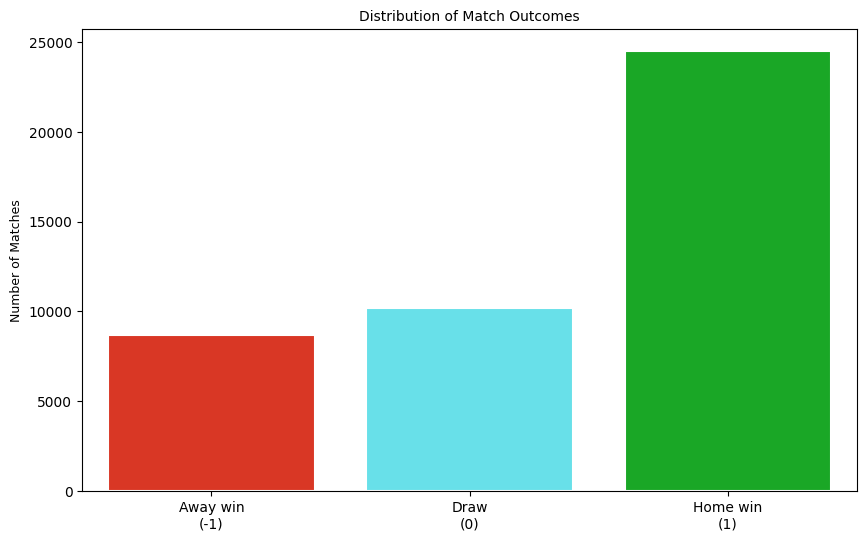

In [17]:
plt.figure(figsize=(10, 6))

labels=['Away win\n(-1)','Draw\n(0)','Home win\n(1)']
counts=df["result"].value_counts().sort_index()
sns.barplot(x=labels,y=counts.values,palette=["#f71f07","#52f3ff","#02bf12"],edgecolor='white',linewidth=1.5)
plt.title("Distribution of Match Outcomes",fontsize=10)
plt.ylabel("Number of Matches",fontsize=9)
plt.show()

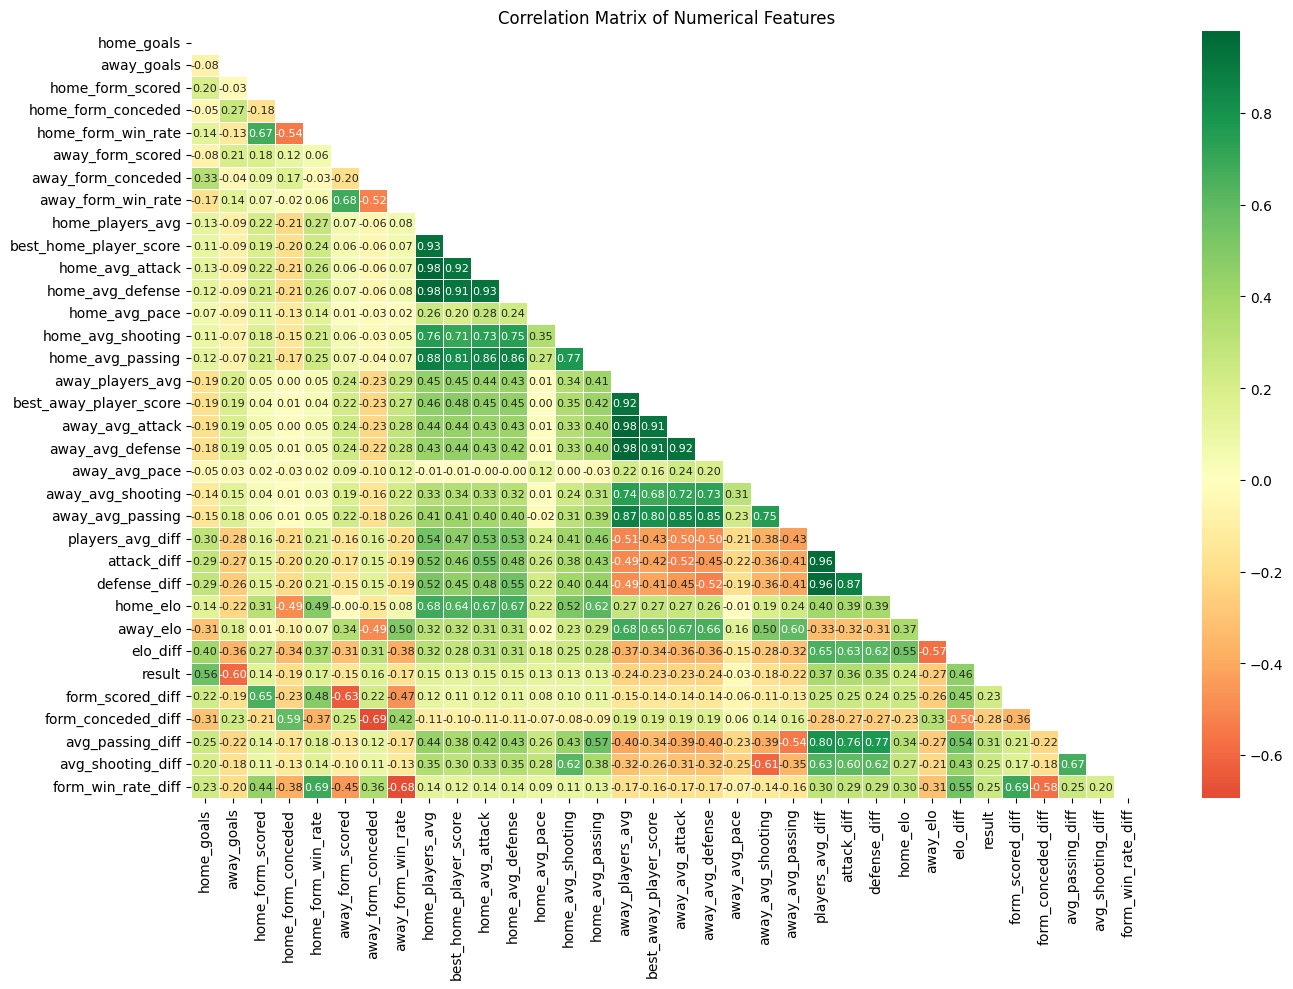

In [18]:
plt.figure(figsize=(14,10))
numeric_cols=df.select_dtypes(include=[np.number]).columns
corr=df[numeric_cols].corr()
mask=np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='RdYlGn',center=0,linewidths=0.5,annot_kws={'size':8},mask=mask)
plt.title("Correlation Matrix of Numerical Features",fontsize=12)
plt.tight_layout()
plt.show()


<h1> Preparing the data for Machine Learning</h1>

In [19]:
features=['home_form_scored','home_form_conceded',
       'home_form_win_rate','away_form_scored','away_form_conceded',
       'away_form_win_rate','home_players_avg','best_home_player_score',
       'home_avg_attack','home_avg_defense','home_avg_pace',
       'home_avg_shooting','home_avg_passing','away_players_avg',
       'best_away_player_score','away_avg_attack','away_avg_defense',
       'away_avg_pace','away_avg_shooting','away_avg_passing',
       'players_avg_diff','attack_diff','defense_diff','home_elo',
       'away_elo','elo_diff','form_scored_diff',
       'form_conceded_diff','avg_passing_diff','avg_shooting_diff',
       'form_win_rate_diff']
       
X=df[features]
y=df["result"]

print('X shape:', X.shape)

X shape: (43364, 31)


In [20]:
#data splitting

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


print('Train set:',X_train.shape)
print('Test set:',X_test.shape)
print('\nClass distribution for train:')
print(pd.Series(y_train).value_counts())

Train set: (34691, 31)
Test set: (8673, 31)

Class distribution for train:
result
2    19593
1     8139
0     6959
Name: count, dtype: int64


In [21]:
print("train set shape :",X_train.shape)
print("test set shape",X_test.shape)
print("\nClass Distribution:")
print(pd.Series(y_train).value_counts())

train set shape : (34691, 31)
test set shape (8673, 31)

Class Distribution:
result
2    19593
1     8139
0     6959
Name: count, dtype: int64


<h1>Classification (Outcome Prediction (win/draw/lose))</h1>

In [22]:
#Standardization
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test) 
     

In [23]:
model=LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)
y_pred=model.predict(X_test_scaled)
y_prob=model.predict_proba(X_test_scaled)


In [24]:
acc=accuracy_score(y_test, y_pred)
prec=precision_score(y_test, y_pred,average='weighted')
rec=recall_score(y_test, y_pred,average='weighted')
f1=f1_score(y_test, y_pred,average='weighted')
rac=roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
cm=confusion_matrix(y_test, y_pred)

print("Accuracy:", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall:", round(rec, 4))
print("F1-score:", round(f1, 4))
print("Roc Auc Score:",round(rac,4))
print("\n===== confusion matrix =====")
print(cm)
print("\n===== Classification report =====")
print(classification_report(y_test, y_pred))

Accuracy: 0.5546
Precision: 0.5904
Recall: 0.5546
F1-score: 0.5658
Roc Auc Score: 0.7282

===== confusion matrix =====
[[1059  404  277]
 [ 629  711  695]
 [ 687 1171 3040]]

===== Classification report =====
              precision    recall  f1-score   support

           0       0.45      0.61      0.51      1740
           1       0.31      0.35      0.33      2035
           2       0.76      0.62      0.68      4898

    accuracy                           0.55      8673
   macro avg       0.50      0.53      0.51      8673
weighted avg       0.59      0.55      0.57      8673



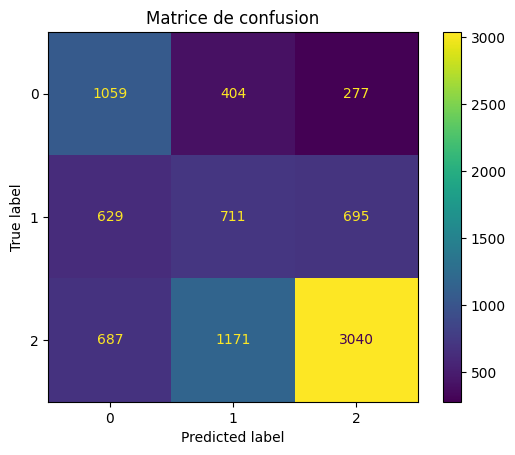

In [25]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,)
plt.title("Matrice de confusion")
plt.show()

In [27]:
models = {
    'KNN':               KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':     DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced'),
    'Random Forest':     RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'XGBoost':           XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                                        eval_metric='mlogloss', random_state=42, n_jobs=-1),
    'LightGBM':          LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                                         random_state=42, n_jobs=-1, verbose=-1, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                     max_depth=5, random_state=42)}

results_clf = {}

for name, clf in models.items():
    model_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', clf)
    ])
    model_pipeline.fit(X_train,y_train)
    y_pred=model_pipeline.predict(X_test)
    y_proba=model_pipeline.predict_proba(X_test)

    results_clf[name] = {
        'model':     model_pipeline,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall':    recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1':        f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'roc_auc':   roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')}

c:\Users\dell\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [28]:
results_clf['Logistic Regression'] = {
    'model':Pipeline([('scaler',StandardScaler()), ('model',model)]),
    'accuracy': acc,'precision':prec,'recall':rec,'f1':f1,'roc_auc':rac
}

metrics_df = pd.DataFrame({
    name: {
        'Accuracy':v['accuracy'],
        'Precision':v['precision'],
        'Recall': v['recall'],
        'F1-score':v['f1'],
        'ROC-AUC':v['roc_auc']}
    for name, v in results_clf.items()
}).T.round(4).sort_values('F1-score',ascending=False)

metrics_df


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.5546,0.5904,0.5546,0.5658,0.7282
LightGBM,0.5522,0.5900,0.5522,0.5649,0.7295
Random Forest,0.6090,0.5586,0.6090,0.5631,0.7194
Decision Tree,0.5491,0.5696,0.5491,0.5570,0.7089
XGBoost,0.6171,0.5606,0.6171,0.5546,0.7324
Gradient Boosting,0.6156,0.5575,0.6156,0.5531,0.7324
KNN,0.5544,0.5437,0.5544,0.5481,0.6673


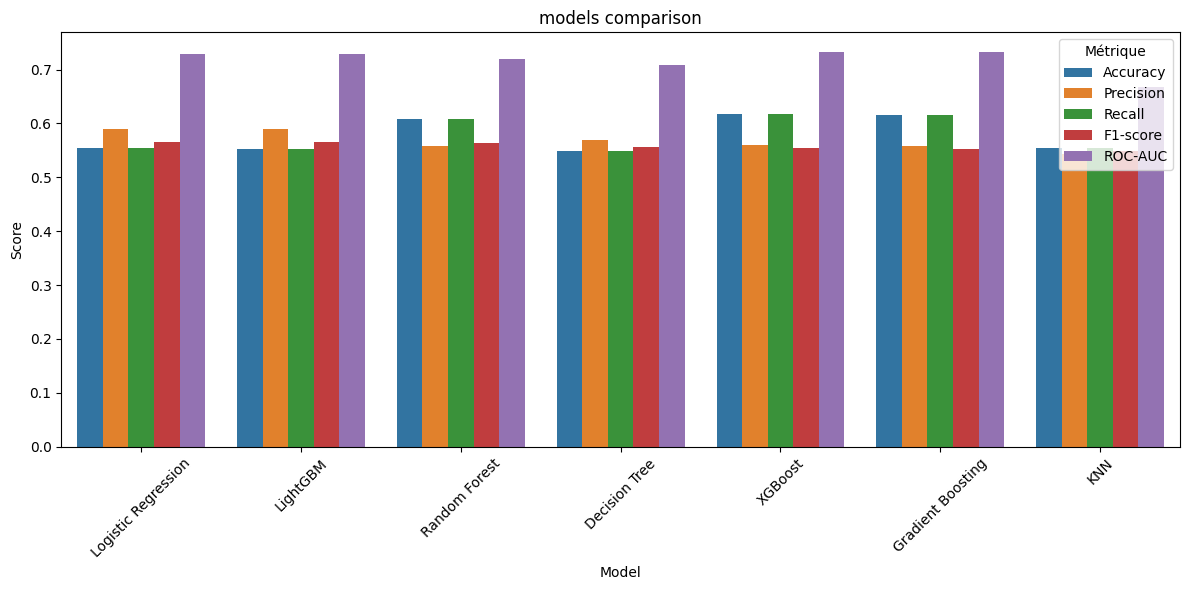

In [29]:
metrics_long=metrics_df.reset_index().melt(id_vars="index",var_name="Metric",value_name="Score")

metrics_long.rename(columns={"index": "Model"}, inplace=True)
plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_long,x="Model",y="Score",hue="Metric")

plt.title("models comparison")
plt.xticks(rotation=45)
plt.legend(title="Métrique")
plt.tight_layout()
plt.show()

In [30]:
best_model_clf = results_clf["XGBoost"]["model"]


<h1>FIFA world cup 2026 simulation</h1>

In [31]:
groups = {"Group A":["Mexico","South Korea","South Africa","Czech Republic"],
          "Group B":["Canada","Switzerland","Qatar","Bosnia and Herzegovina"],
          "Group C":["Brazil","Morocco","Haiti","Scotland"],
          "Group D":["United States","Paraguay","Australia","Turkey"],
          "Group E":["Germany","Ecuador","Ivory Coast","Curacao"],
          "Group F":["Netherlands","Japan","Sweden","Tunisia"],
          "Group G":["Belgium","Iran","Egypt","New Zealand"],
          "Group H":["Spain","Uruguay","Saudi Arabia","Cape Verde"],
          "Group I":["France","Senegal","Norway","Iraq"],
          "Group J":["Argentina","Algeria","Austria","Jordan"],
          "Group K":["Portugal","Colombia","Uzbekistan","DR Congo"],
          "Group L":["England","Croatia","Ghana","Panama"]}

In [32]:
def get_team_stats(team,df):
    home_rows=df[df['home_team']==team].sort_values('date').tail(5)
    away_rows=df[df['away_team']==team].sort_values('date').tail(5)

    if not home_rows.empty:
        r=home_rows.iloc[-1]
        return {
            'elo':r['home_elo'],'form_scored':r['home_form_scored'],
            'form_conceded':r['home_form_conceded'],'form_win_rate':r['home_form_win_rate'],
            'players_avg':r['home_players_avg'],'avg_attack':r['home_avg_attack'],
            'avg_defense':r['home_avg_defense'],'avg_pace':r['home_avg_pace'],
            'avg_shooting':r['home_avg_shooting'],'avg_passing':r['home_avg_passing'],
            'best_player':r['best_home_player_score']}
    elif not away_rows.empty:
        r=away_rows.iloc[-1]
        return {
            'elo':r['away_elo'],'form_scored':r['away_form_scored'],
            'form_conceded':r['away_form_conceded'],'form_win_rate':r['away_form_win_rate'],
            'players_avg':r['away_players_avg'],'avg_attack':r['away_avg_attack'],
            'avg_defense':r['away_avg_defense'],'avg_pace':r['away_avg_pace'],
            'avg_shooting':r['away_avg_shooting'],'avg_passing':r['away_avg_passing'],
            'best_player':r['best_away_player_score']}
    else:
        return {
            'elo': 1500.0,'form_scored': 1.2,'form_conceded':1.2,'form_win_rate': 0.33,
            'players_avg': 72.0, 'avg_attack': 70.0, 'avg_defense': 70.0,
            'avg_pace': 70.0, 'avg_shooting': 65.0, 'avg_passing': 68.0, 'best_player': 75,
        }

all_teams=[team for group in groups.values() for team in group]
team_stats={team:get_team_stats(team,df) for team in all_teams}


In [33]:
def build_match_features(home,away):
    h=team_stats.get(home,list(team_stats.values())[0])
    a=team_stats.get(away,list(team_stats.values())[0])
    elo_diff=h['elo']-a['elo']
    row = {
        'home_elo':h['elo'],'away_elo':a['elo'],'elo_diff':elo_diff,
        'home_form_scored': h['form_scored'],'home_form_conceded':h['form_conceded'],
        'home_form_win_rate':h['form_win_rate'],
        'away_form_scored':a['form_scored'],'away_form_conceded':a['form_conceded'],
        'away_form_win_rate':a['form_win_rate'],
        'form_scored_diff':h['form_scored']-a['form_scored'],
        'form_conceded_diff':h['form_conceded']-a['form_conceded'],
        'form_win_rate_diff':h['form_win_rate']-a['form_win_rate'],
        'home_players_avg':h['players_avg'],'away_players_avg':a['players_avg'],
        'players_avg_diff':h['players_avg']-a['players_avg'],
        'home_avg_attack':h['avg_attack'],'home_avg_defense':h['avg_defense'],
        'home_avg_pace':h['avg_pace'],'home_avg_shooting':h['avg_shooting'],
        'home_avg_passing':h['avg_passing'],
        'away_avg_attack':a['avg_attack'],'away_avg_defense':a['avg_defense'],
        'away_avg_pace':a['avg_pace'],'away_avg_shooting':a['avg_shooting'],
        'away_avg_passing':a['avg_passing'],
        'attack_diff':h['avg_attack']-a['avg_attack'],
        'defense_diff':h['avg_defense']-a['avg_defense'],
        'avg_passing_diff':h['avg_passing']-a['avg_passing'],
        'avg_shooting_diff':h['avg_shooting']-a['avg_shooting'],
        'best_home_player_score':h['best_player'],
        'best_away_player_score':a['best_player']}
    return pd.DataFrame([row])[features]


def simulate_match(team1, team2):
    
    #features team1 vs team2
    x1=build_match_features(team1, team2)
    proba1=best_model_clf.predict_proba(x1)[0]   

    #features team2 vs team1
    x2=build_match_features(team2, team1)
    proba2 = best_model_clf.predict_proba(x2)[0]   

    #probabilies mean
    p_team1_win= (proba1[2]+proba2[0])/2
    p_draw= (proba1[1]+proba2[1])/2
    p_team1_lose = (proba1[0]+proba2[2])/2

    
    probs = np.array([p_team1_win,p_draw,p_team1_lose], dtype=np.float64)
    probs = np.clip(probs, 0, 1)   
    probs /= probs.sum()    

    #titage des probabilities 
    outcome = [1, 0, -1][np.argmax(probs)]
    return outcome,(float(probs[0]),float(probs[1]),float(probs[2]))



<h1>Group stage</h1>

In [34]:
def simulate_group_stage(groups):
    
    all_matches = []
    group_standings = {}

    for group_name,teams in groups.items():
        standings={t: {'pts': 0} for t in teams}
        matches=[]
        for t1,t2 in itertools.combinations(teams, 2):
            result,proba=simulate_match(t1, t2)
            
            matches.append({
                'group':group_name,'team1':t1,'team2':t2,
                'result':result,
                'p_team1_win':proba[0],'p_draw':proba[1],'p_team1_lose':proba[2]
            })
            
            if result==1:      
                standings[t1]['pts']+=3                
            elif result==-1:  
                standings[t2]['pts']+=3
            else:                
                standings[t1]['pts']+=1
                standings[t2]['pts']+=1

        
        ranked = sorted(standings.items(),key=lambda x: (x[1]['pts']),reverse=True)
        group_standings[group_name]={'ranked':ranked,'matches':matches}
        all_matches.extend(matches)

    return group_standings,all_matches

np.random.seed(42)
group_standings,group_matches=simulate_group_stage(groups)

In [36]:
def display_group_standings(group_standings):
    rows = []
    for group_name,data in group_standings.items():
        for rank,(team, s) in enumerate(data['ranked'],1):
            rows.append({'Groupe':group_name,'Rank':rank,'Team':team,'Pts':s['pts'],
                'Qualified': '✅' if rank <= 2 else ('❎' if rank == 3 else '❌')})
    return pd.DataFrame(rows)

standings_df = display_group_standings(group_standings)

for group in groups.keys():
    sub = standings_df[standings_df['Groupe'] == group][['Rank','Team','Pts','Qualified']]
    print(f'{group}')
    print(sub.to_string(index=False))
    print("-"*50)

Group A
 Rank           Team  Pts Qualified
    1         Mexico    9         ✅
    2 Czech Republic    6         ✅
    3    South Korea    3         ❎
    4   South Africa    0         ❌
--------------------------------------------------
Group B
 Rank                   Team  Pts Qualified
    1            Switzerland    9         ✅
    2                 Canada    6         ✅
    3 Bosnia and Herzegovina    3         ❎
    4                  Qatar    0         ❌
--------------------------------------------------
Group C
 Rank     Team  Pts Qualified
    1   Brazil    9         ✅
    2  Morocco    6         ✅
    3 Scotland    3         ❎
    4    Haiti    0         ❌
--------------------------------------------------
Group D
 Rank          Team  Pts Qualified
    1        Turkey    9         ✅
    2 United States    6         ✅
    3      Paraguay    3         ❎
    4     Australia    0         ❌
--------------------------------------------------
Group E
 Rank        Team  Pts Qualifie

<h1>Knockout phase</h2>

In [37]:
def get_qualified_teams(group_standings):

    top2,top3 ={},[]

    for g,data in group_standings.items():
        ranked=data['ranked']
        top2[g] ={'1st':ranked[0][0],'2nd':ranked[1][0]}
        if len(ranked) >= 3:
            top3.append((g,ranked[2][0],ranked[2][1]))

    top3_sorted=sorted(top3,key=lambda x:(x[2]['pts']),reverse=True)
    best8=top3_sorted[:8]

    print('qualified team:')
    print('\n  1st and 2nd of each group:')
    for g,t in top2.items():
        print(f'{g} : 1st: {t["1st"]} | 2nd: {t["2nd"]}')

    print('\n  Top 3 :')
    for i, (grp, team, stats) in enumerate(best8, 1):
        print(f'- {team} ')

    best8_teams=[t[1] for t in best8]
    best8_groups=[t[0] for t in best8]
    return top2, best8_teams, best8_groups

top2, best8_thirds, best8_groups = get_qualified_teams(group_standings)

qualified team:

  1st and 2nd of each group:
Group A : 1st: Mexico | 2nd: Czech Republic
Group B : 1st: Switzerland | 2nd: Canada
Group C : 1st: Brazil | 2nd: Morocco
Group D : 1st: Turkey | 2nd: United States
Group E : 1st: Germany | 2nd: Ecuador
Group F : 1st: Netherlands | 2nd: Japan
Group G : 1st: Belgium | 2nd: Iran
Group H : 1st: Spain | 2nd: Uruguay
Group I : 1st: France | 2nd: Norway
Group J : 1st: Argentina | 2nd: Austria
Group K : 1st: Colombia | 2nd: Portugal
Group L : 1st: England | 2nd: Croatia

  Top 3 :
- South Korea 
- Bosnia and Herzegovina 
- Scotland 
- Paraguay 
- Ivory Coast 
- Sweden 
- Egypt 
- Saudi Arabia 


In [38]:
def simulate_knockout_match(team1,team2):
    
    result,proba=simulate_match(team1,team2)
    winner = team1 if result == 1 else team2
    return winner,proba


def simulate_round_display(matches_list, stage_name):
    winners,results =[],[]
    print('-'*70)
    print(f'{stage_name}')
    for match_id,(t1,t2) in matches_list:
        winner, proba= simulate_knockout_match(t1, t2)
        results.append({
            'stage':stage_name,'match':match_id,
            'team1':t1,'team2':t2,'winner': winner,
            'p_t1':f'{proba[0]:.1%}','p_draw':f'{proba[1]:.1%}','p_t2':f'{proba[2]:.1%}'
        })
        winners.append(winner)
        print("="*70)
        print(f' {t1} vs {t2} : {winner}')
        print(f'P(win/draw/lose) : {proba[0]:.1%} / {proba[1]:.1%} / {proba[2]:.1%}')
        print("="*70)
    return winners,results

In [39]:
def assign_best_thirds(best8_thirds, best8_groups):
    slots={
        'M74':{'A','B','C','D','F'},
        'M77':{'C','D','F','G','H'},
        'M79':{'C','E','F','H','I'},
        'M80':{'E','H','I','J','K'},
        'M81':{'B','E','F','I','J'},
        'M82':{'A','E','H','I','J'},
        'M85':{'E','F','G','I','J'},
        'M87':{'D','E','I','J','L'}}
    
    slot_order=['M74','M77','M79','M80','M81','M82','M85','M87']
    assigned={} 
    used_teams=set()

    for slot in slot_order:
        sloted=slots[slot]
        for grp,team in zip(best8_groups, best8_thirds):
            key=grp.replace('Group ', '')   
            if key in sloted and team not in used_teams:
                assigned[slot]=team
                used_teams.add(team)
                break
        if slot not in assigned:
            assigned[slot] = 'Senegal' 

    return assigned

third_slots=assign_best_thirds(best8_thirds,best8_groups)

for slot, team in third_slots.items():
    print(f'  {slot} : {team}')

  M74 : South Korea
  M77 : Scotland
  M79 : Ivory Coast
  M80 : Saudi Arabia
  M81 : Bosnia and Herzegovina
  M82 : Senegal
  M85 : Sweden
  M87 : Paraguay


In [40]:
def build_round32_bracket(top2,third_slots):
    
    g={grp[-1]:{'1st':t['1st'],'2nd':t['2nd']} for grp,t in top2.items()}
    
    bracket=[('M73',(g['B']['2nd'],g['A']['2nd']))]
    
    bracket=[
        ('M73',(g['A']['2nd'],g['B']['2nd'])),
        ('M74',(g['E']['1st'],third_slots['M74'])),
        ('M75',(g['F']['1st'],g['C']['2nd'])),
        ('M76',(g['C']['1st'],g['F']['2nd'])),
        ('M77',(g['I']['1st'],third_slots['M77'])),
        ('M78',(g['E']['2nd'],g['I']['2nd'])),
        ('M79',(g['A']['1st'],third_slots['M79'])),
        ('M80',(g['L']['1st'],third_slots['M80'])),
        ('M81',(g['D']['1st'],third_slots['M81'])),
        ('M82',(g['G']['1st'],third_slots['M82'])),
        ('M83',(g['K']['2nd'],g['L']['2nd'])),
        ('M84',(g['H']['1st'],g['J']['2nd'])),
        ('M85',(g['B']['1st'],third_slots['M85'])),
        ('M86',(g['J']['1st'],g['H']['2nd'])),
        ('M87',(g['K']['1st'],third_slots['M87'])),
        ('M88',(g['D']['2nd'],g['G']['2nd']))]
    return bracket

r32_bracket=build_round32_bracket(top2,third_slots)
print('Bracket Round of 32 :')
for m,(t1,t2) in r32_bracket:
    print(f'{m}: {t1} vs {t2}')

Bracket Round of 32 :
M73: Czech Republic vs Canada
M74: Germany vs South Korea
M75: Netherlands vs Morocco
M76: Brazil vs Japan
M77: France vs Scotland
M78: Ecuador vs Norway
M79: Mexico vs Ivory Coast
M80: England vs Saudi Arabia
M81: Turkey vs Bosnia and Herzegovina
M82: Belgium vs Senegal
M83: Portugal vs Croatia
M84: Spain vs Austria
M85: Switzerland vs Sweden
M86: Argentina vs Uruguay
M87: Colombia vs Paraguay
M88: United States vs Iran


In [41]:
np.random.seed(42)
all_results=[]

#Round of 32
r32_winners,r32_res=simulate_round_display(r32_bracket, 'Round of 32')
all_results.extend(r32_res)

w={res['match']:res['winner'] for res in r32_res}

#Round of 16
r16_bracket = [
    ('M89',(w['M74'],w['M77'])),
    ('M90',(w['M73'],w['M75'])),
    ('M91',(w['M76'],w['M78'])),
    ('M92',(w['M79'],w['M80'])),
    ('M93',(w['M83'],w['M84'])),
    ('M94',(w['M81'],w['M82'])),
    ('M95',(w['M86'],w['M88'])),
    ('M96',(w['M85'],w['M87']))]

r16_winners,r16_res=simulate_round_display(r16_bracket,'Round of 16')
all_results.extend(r16_res)
w.update({res['match']: res['winner'] for res in r16_res})

#Quarter final
qf_bracket = [
    ('M97',(w['M89'], w['M90'])),
    ('M98',(w['M93'], w['M94'])),
    ('M99',(w['M91'], w['M92'])),
    ('M100',(w['M95'], w['M96']))]

qf_winners,qf_res=simulate_round_display(qf_bracket,'Quarter final')
all_results.extend(qf_res)
w.update({res['match']: res['winner'] for res in qf_res})

#Semi final:
sf_bracket = [
    ('M101',(w['M97'],w['M98'])),
    ('M102',(w['M99'],w['M100']))]

sf_winners,sf_res=simulate_round_display(sf_bracket,'Semi final')
all_results.extend(sf_res)
w.update({res['match']: res['winner'] for res in sf_res})

#3rd place
sf_losers=[]
for res in sf_res:
    loser=res['team2'] if res['winner'] == res['team1'] else res['team1']
    sf_losers.append(loser)
print('-'*70)
print('Match of 3rd place :\n')
third_winner,third_proba=simulate_knockout_match(sf_losers[0], sf_losers[1])
fourth_place = sf_losers[1] if third_winner == sf_losers[0] else sf_losers[0]
print(f'  [M103] {sf_losers[0]} vs {sf_losers[1]} : {third_winner}')
print(f'P(win/draw/lose) : {third_proba[0]:.1%} / {third_proba[1]:.1%} / {third_proba[2]:.1%}')

#Final
print('-'*70)
print('World cup 2026 final :')
final_winner,final_proba=simulate_knockout_match(w['M101'], w['M102'])
runner_up = w['M102'] if final_winner == w['M101'] else w['M101']
print(f'{w["M101"]} vs {w["M102"]} : {final_winner}')
print(f'P(win/draw/lose) : {final_proba[0]:.1%} / {final_proba[1]:.1%} / {final_proba[2]:.1%}')

print('-'*70)
print(f'🥇 World cup champion : {final_winner}')
print(f'🥈 Finaliste : {runner_up}')
print(f'🥉 3rd place : {third_winner}')
print(f'4th place : {fourth_place}')

----------------------------------------------------------------------
Round of 32
 Czech Republic vs Canada : Canada
P(win/draw/lose) : 34.7% / 30.1% / 35.3%
 Germany vs South Korea : Germany
P(win/draw/lose) : 54.8% / 23.6% / 21.6%
 Netherlands vs Morocco : Netherlands
P(win/draw/lose) : 40.8% / 31.4% / 27.8%
 Brazil vs Japan : Brazil
P(win/draw/lose) : 55.5% / 21.4% / 23.2%
 France vs Scotland : France
P(win/draw/lose) : 54.6% / 25.6% / 19.8%
 Ecuador vs Norway : Norway
P(win/draw/lose) : 33.3% / 37.2% / 29.5%
 Mexico vs Ivory Coast : Mexico
P(win/draw/lose) : 42.7% / 32.9% / 24.4%
 England vs Saudi Arabia : England
P(win/draw/lose) : 68.2% / 20.3% / 11.5%
 Turkey vs Bosnia and Herzegovina : Turkey
P(win/draw/lose) : 59.4% / 19.3% / 21.3%
 Belgium vs Senegal : Belgium
P(win/draw/lose) : 39.1% / 32.8% / 28.2%
 Portugal vs Croatia : Portugal
P(win/draw/lose) : 38.4% / 32.9% / 28.8%
 Spain vs Austria : Spain
P(win/draw/lose) : 46.7% / 35.7% / 17.5%
 Switzerland vs Sweden : Switzerland


In [42]:
df_results = pd.DataFrame(all_results)
df_results[['stage','team1','team2','winner','p_t1','p_draw','p_t2']]

,stage,team1,team2,winner,p_t1,p_draw,p_t2
0,Round of 32,Czech Republic,Canada,Canada,34.7%,30.1%,35.3%
1,Round of 32,Germany,South Korea,Germany,54.8%,23.6%,21.6%
2,Round of 32,Netherlands,Morocco,Netherlands,40.8%,31.4%,27.8%
3,Round of 32,Brazil,Japan,Brazil,55.5%,21.4%,23.2%
4,Round of 32,France,Scotland,France,54.6%,25.6%,19.8%
5,Round of 32,Ecuador,Norway,Norway,33.3%,37.2%,29.5%
6,Round of 32,Mexico,Ivory Coast,Mexico,42.7%,32.9%,24.4%
7,Round of 32,England,Saudi Arabia,England,68.2%,20.3%,11.5%
8,Round of 32,Turkey,Bosnia and Herzegovina,Turkey,59.4%,19.3%,21.3%
9,Round of 32,Belgium,Senegal,Belgium,39.1%,32.8%,28.2%


In [44]:


print(f'🏆 Champion : {final_winner}')
print(f'🥈 Finaliste : {runner_up}')
print(f'🥉 3e place  : {third_winner}')

🏆 Champion : Argentina
🥈 Finaliste : Spain
🥉 3e place  : France
